In [15]:
from time import time
import mininumpy as mnp
import random
import matplotlib.pyplot as plt

In [17]:
n = [2, 3, 4, 5, 6, 7]
n_gau = [150, 160, 170, 180, 190, 200]

# Build test matrices
tests = [
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n],
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n_gau]
]

det = {}
timer = {}
times = 3

for algo in ['recursion', 'LU', 'gaussian']:

    det[algo] = []
    timer[algo] = []

    # choose the correct test size group
    if algo == 'recursion':
        dataset = tests[0]      # small matrices
    else:
        dataset = tests[1]      # large matrices

    for i in range(len(dataset)):
        delta_t = 0
        for t in range(times):
            start = time()
            d = mnp.minilinalg.inv(dataset[i], algo=algo)
            stop = time()
            delta_t += stop - start

        det[algo].append(d)
        timer[algo].append(delta_t / times)

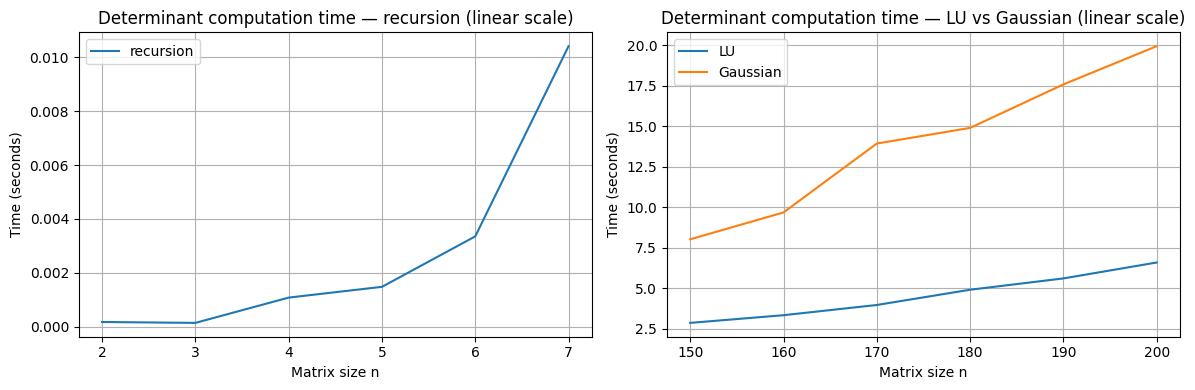

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: recursion alone ---
axes[0].plot(n, timer["recursion"], label="recursion")
axes[0].set_xlabel("Matrix size n")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title("Determinant computation time — recursion (linear scale)")
axes[0].grid(True, which="both")
axes[0].legend()


# --- Plot 2: LU + Gaussian together ---
axes[1].plot(n_gau, timer["LU"], label="LU")
axes[1].plot(n_gau, timer["gaussian"], label="Gaussian")
axes[1].set_xlabel("Matrix size n")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title("Determinant computation time — LU vs Gaussian (linear scale)")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

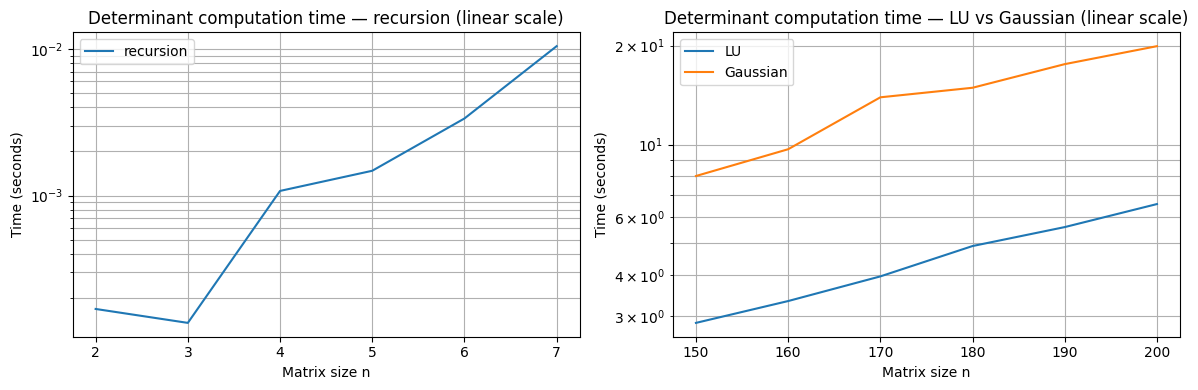

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: recursion alone ---
axes[0].plot(n, timer["recursion"], label="recursion")
axes[0].set_yscale("log")
axes[0].set_xlabel("Matrix size n")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title("Determinant computation time — recursion (linear scale)")
axes[0].grid(True, which="both")
axes[0].legend()


# --- Plot 2: LU + Gaussian together ---
axes[1].plot(n_gau, timer["LU"], label="LU")
axes[1].plot(n_gau, timer["gaussian"], label="Gaussian")
axes[1].set_yscale("log")
axes[1].set_xlabel("Matrix size n")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title("Determinant computation time — LU vs Gaussian (linear scale)")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()